# Q-Commerce Stockout Prediction Pipeline
**Project:** Advanced Machine Learning for Business Transformation (AMLBT)
**Team:** Nishant Khandelwal, Anwesha Banerjee, Anisha Saha

This notebook executes the data preprocessing, model training, and evaluation for predicting inventory failure.

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.7/48.9 MB 15.8 MB/s eta 0:00:03
   ----- ---------------------------------- 7.3/48.9 MB 16.4 MB/s eta 0:00:03
   -------- ------------------------------- 11.0/48.9 MB 17.0 MB/s eta 0:00:03
   ------------ --------------------------- 14.9/48.9 MB 17.5 MB/s eta 0:00:02
   --------------- ------------------------ 19.1/48.9 MB 17.9 MB/s eta 0:00:02
   ------------------- -------------------- 23.3/48.9 MB 18.4 MB/s eta 0:00:02
   --------------------- ------------------ 26.7/48.9 MB 18.3 MB/s eta 0:00:02
   ------------------------ --------------- 30.1/48.9 MB 18.0 MB/s eta 0:00:02
   --------------------------- ------------ 33.8/48.9 MB 17.8 MB/s eta 0:00:01
   ------------------------------ --------- 37.2/48.9 MB 17.8 MB/s eta 0:00:01
   --------------------------------- ------ 41.2/48.9 MB 17.9 MB/s eta 0

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

In [4]:
# 1. Load the dataset from the root directory
df = pd.read_csv('cleaned_inventory_optimization.csv')

# Print columns to verify mappings
print("Dataset Columns:", df.columns.tolist())

# 2. Define the target variable
target_col = 'stockout_occurred' 
if target_col not in df.columns:
    target_col = df.columns[-1] # Fallback to the last column if naming differs

df = df.dropna(subset=[target_col])

# 3. Identify and impute numerical features
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 4. Scale continuous features for the Logistic Regression baseline
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nData Preprocessing Complete. Current shape:", df.shape)
display(df.head())

Dataset Columns: ['sku_id', 'category', 'ignores_lead_time_variability', 'mean_daily_demand', 'sigma_daily_demand', 'demand_cv', 'mean_lead_time', 'sigma_lead_time', 'lead_time_cv', 'unit_cost', 'holding_rate_annual', 'stockout_penalty', 'order_cost', 'target_service_level', 'safety_stock', 'reorder_point', 'order_quantity', 'realized_demand_lt', 'stockout_frequency', 'units_short', 'units_excess', 'holding_cost', 'shortage_cost', 'spoilage_cost', 'total_cost', 'optimal_service_level', 'service_level_gap', 'stockout_occurred', 'lead_time_demand_proxy']

Data Preprocessing Complete. Current shape: (45000, 29)


,sku_id,category,ignores_lead_time_variability,mean_daily_demand,sigma_daily_demand,demand_cv,mean_lead_time,sigma_lead_time,lead_time_cv,unit_cost,...,units_short,units_excess,holding_cost,shortage_cost,spoilage_cost,total_cost,optimal_service_level,service_level_gap,stockout_occurred,lead_time_demand_proxy
0,SKU000000,high_value,0.909825,-0.918050,-0.693760,-0.072758,-0.081745,0.577359,1.235781,2.435198,...,0.349710,-0.552720,-0.025179,2.448629,-0.160734,2.304967,0.616392,-0.551696,1,high_value
1,SKU000001,perishable,0.909825,-0.829729,-0.786758,-0.764291,0.516611,1.590683,1.633307,-0.589453,...,-0.131939,-0.609889,-0.261581,-0.165981,0.273397,-0.171749,-0.063416,-0.426738,1,perishable
2,SKU000002,fast_mover,0.909825,-0.611871,-0.802931,-1.130397,0.031153,0.504233,0.863495,-0.477026,...,0.583645,-0.507298,-0.255466,-0.100389,-0.160734,-0.139419,0.130815,1.144165,1,fast_mover
3,SKU000003,fast_mover,-1.099112,-1.053475,-0.942140,-1.171076,-0.059165,0.457223,0.951834,-0.677217,...,-0.426380,-0.455395,-0.270161,-0.192304,-0.160734,-0.236837,0.227930,-0.480292,0,NaN
4,SKU000004,seasonal,0.909825,1.719796,1.111331,-0.133776,-0.657521,-0.853830,-1.174614,-0.633568,...,-0.426380,-0.071818,-0.265305,-0.192304,-0.160734,-0.227628,0.325046,-0.498143,0,seasonal


In [8]:
# Separate features and target variable
# Drop the target variable AND the leaking 'stockout_frequency' column
X = df.drop(columns=[target_col, 'stockout_frequency'])
y = df[target_col]
# Convert categorical variables to dummy variables if any remain
X = pd.get_dummies(X, drop_first=True)

# 70-30 Train-Test Split (stratified to handle class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (31500, 45033)
Testing features shape: (13500, 45033)


In [9]:
# Initialize models
models = {
    "Logistic Regression (Baseline)": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

# Train and evaluate each model
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    preds = model.predict(X_test)
    
    # Evaluate
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    print(f"--- {name} ---")
    print(f"Precision : {precision:.2f}")
    print(f"Recall    : {recall:.2f}")
    print(f"F1-Score  : {f1:.2f}\n")

--- Logistic Regression (Baseline) ---
Precision : 0.86
Recall    : 0.75
F1-Score  : 0.80

--- Random Forest ---
Precision : 0.00
Recall    : 0.00
F1-Score  : 0.00

--- XGBoost ---
Precision : 0.85
Recall    : 0.84
F1-Score  : 0.84



<Figure size 800x500 with 0 Axes>

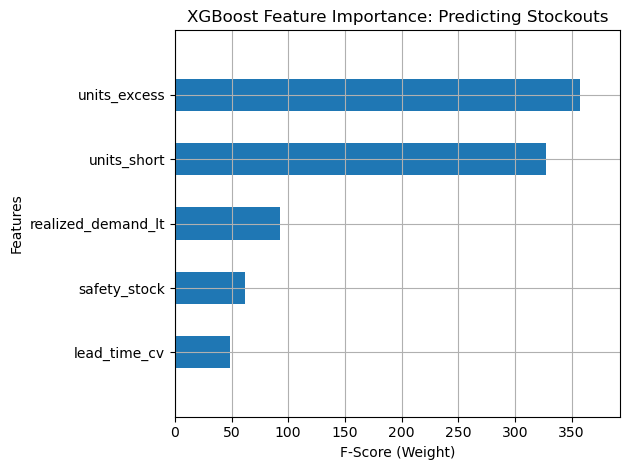

In [10]:
# Extract XGBoost model from the dictionary
xgb_model = models["XGBoost"]

# Plot feature importance
plt.figure(figsize=(8, 5))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5, height=0.5, show_values=False)
plt.title('XGBoost Feature Importance: Predicting Stockouts')
plt.ylabel('Features')
plt.xlabel('F-Score (Weight)')
plt.tight_layout()
plt.show()